# Dynamic Solvency & Risk Simulator

 ## Data Engineering & Feature Creation

In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import requests
import tabulate
import logging

In [45]:

logging.basicConfig(level=logging.INFO, format="%(levelname)s | %(message)s")
logger = logging.getLogger(__name__)

SEC_HEADERS = {
    "User-Agent": "eliaslaspatzakes@gmail.com",
    "Accept-Encoding": "gzip, deflate",
}

CONCEPTS = {
    "Total_Revenue": ["Revenue","Revenues", "RevenueFromContractWithCustomerExcludingAssessedTax", "SalesRevenueNet"],
    "Cost_Of_Revenue": ["CostOfRevenue"],
    "Operating_Expenses": ["OperatingExpenses"],
    "EBIT": ["OperatingIncomeLoss"],
    "Total_Assets": ["Assets"],
    "Total_Liabilities": ["Liabilities"],
    "Current_Assets": ["AssetsCurrent"],
    "Current_Liabilities": ["LiabilitiesCurrent"],
    "Retained_Earnings": ["RetainedEarningsAccumulatedDeficit"],
    "Equity": ["StockholdersEquity"],
    "Gross_Profit": ["GrossProfit"],
  
}


def get_sec_ticker_map() -> dict[str, str]:
    url = "https://www.sec.gov/files/company_tickers.json"
    response = requests.get(url, headers=SEC_HEADERS, timeout=30)
    response.raise_for_status()

    raw = response.json()
    return {
        item["ticker"].upper(): str(item["cik_str"]).zfill(10)
        for item in raw.values()
    }


def extract_usd_facts(companyfacts: dict, concept_candidates: list[str]) -> pd.DataFrame:
    facts = companyfacts.get("facts", {}).get("us-gaap", {})

    for concept in concept_candidates:
        concept_data = facts.get(concept)
        if not concept_data:
            continue

        usd_facts = concept_data.get("units", {}).get("USD", [])
        rows = []

        for item in usd_facts:
            if item.get("form") != "10-K":
                continue

            if item.get("fp") != "FY":
                continue

            rows.append({
                "Fiscal_Year_Num": item.get("fy"),
                "Fiscal_Year": pd.to_datetime(item.get("end"), errors="coerce"),
                "Filed": pd.to_datetime(item.get("filed"), errors="coerce"),
                "value": item.get("val"),
            })

        df = pd.DataFrame(rows)

        if df.empty:
            continue

        df = df.dropna(subset=["Fiscal_Year", "Fiscal_Year_Num"])
        df = df.sort_values(["Fiscal_Year_Num", "Filed"])
        df = df.drop_duplicates(subset=["Fiscal_Year_Num"], keep="last")

        return df[["Fiscal_Year_Num", "Fiscal_Year", "value"]]

    return pd.DataFrame(columns=["Fiscal_Year_Num", "Fiscal_Year", "value"])


def fetch_3yr_financial_data_sec(tickers: list[str]) -> pd.DataFrame:
    ticker_map = get_sec_ticker_map()
    output_rows = []

    for ticker in tickers:
        ticker = ticker.upper()
        logger.info("Άντληση SEC financials για: %s", ticker)

        cik = ticker_map.get(ticker)
        if cik is None:
            logger.warning("Δεν βρέθηκε CIK για το ticker %s. Παραλείπεται.", ticker)
            continue

        url = f"https://data.sec.gov/api/xbrl/companyfacts/CIK{cik}.json"

        try:
            response = requests.get(url, headers=SEC_HEADERS, timeout=30)
            response.raise_for_status()
            companyfacts = response.json()
        except requests.RequestException as exc:
            logger.warning("Αποτυχία SEC request για %s: %s", ticker, exc)
            continue

        per_metric = []

        for output_name, candidates in CONCEPTS.items():
            metric_df = extract_usd_facts(companyfacts, candidates)
            metric_df = metric_df.rename(columns={"value": output_name})
            per_metric.append(metric_df)

        company_df = None

        for metric_df in per_metric:
            if metric_df.empty:
                continue

            if company_df is None:
                company_df = metric_df
            else:
                company_df = company_df.merge(
                    metric_df,
                    on=["Fiscal_Year_Num", "Fiscal_Year"],
                    how="outer",
                )

        if company_df is None or company_df.empty:
            logger.warning("Δεν βρέθηκαν 10-K financial facts για %s.", ticker)
            continue

        company_df["Ticker"] = ticker
        company_df = company_df.sort_values("Fiscal_Year").tail(3)
        output_rows.append(company_df)

        time.sleep(0.2)

    if not output_rows:
        raise ValueError("Δεν αντλήθηκαν SEC financials για κανένα ticker.")

    df = pd.concat(output_rows, ignore_index=True)
    df["Fiscal_Year"] = pd.to_datetime(df["Fiscal_Year"]).dt.normalize()

    return df.sort_values(["Ticker", "Fiscal_Year"]).reset_index(drop=True)


def fetch_fred_series(series_id: str, column_name: str) -> pd.DataFrame:
    url = f"https://fred.stlouisfed.org/graph/fredgraph.csv?id={series_id}"
    df = pd.read_csv(url, na_values=".")

    df["observation_date"] = pd.to_datetime(df["observation_date"])
    df = df.rename(columns={series_id: column_name})
    df = df.set_index("observation_date")

    return df[[column_name]]


def fetch_macro_data_fred() -> pd.DataFrame:
    logger.info("Άντληση macro δεδομένων από FRED")

    sp500 = fetch_fred_series("SP500", "SP500")
    dgs10 = fetch_fred_series("DGS10", "Interest_Rate_10Yr")
    vix = fetch_fred_series("VIXCLS", "VIX")

    macro_df = pd.concat([sp500, dgs10, vix], axis=1)
    macro_df = macro_df.sort_index().ffill().dropna()

    return macro_df


# Το διευρυμένο portfolio μας (12 Εταιρείες)
portfolio = [
    'URBN', 'SHAK', 'GPRO', 'FSLY', 'TNC',
    'ROKU', 'KSS', 'PLAY', 'TDOC', 'TEX', 'YETI' 
]

logger.info("Συγχώνευση SEC financials και FRED macro data")

company_df = fetch_3yr_financial_data_sec(portfolio)
macro_df = fetch_macro_data_fred()

df_final = pd.merge_asof(
    company_df.sort_values("Fiscal_Year"),
    macro_df.sort_index(),
    left_on="Fiscal_Year",
    right_index=True,
    direction="backward",
)

df_final = df_final.sort_values(["Ticker", "Fiscal_Year"]).reset_index(drop=True)

display_columns = [
    "Ticker",
    "Fiscal_Year",
   "Total_Revenue",
    "Cost_Of_Revenue",
    "Operating_Expenses",
    "EBIT",
    "Total_Assets",
    "Total_Liabilities",
    "Current_Assets",
    "Current_Liabilities",
    "Retained_Earnings",
    "Equity",
    "SP500",
    "Interest_Rate_10Yr",
    "VIX",
    "Gross_Profit",
    
   
    
]


INFO | Συγχώνευση SEC financials και FRED macro data
INFO | Άντληση SEC financials για: URBN
INFO | Άντληση SEC financials για: SHAK
INFO | Άντληση SEC financials για: GPRO
INFO | Άντληση SEC financials για: FSLY
INFO | Άντληση SEC financials για: TNC
INFO | Άντληση SEC financials για: ROKU
INFO | Άντληση SEC financials για: KSS
INFO | Άντληση SEC financials για: PLAY
INFO | Άντληση SEC financials για: TDOC
INFO | Άντληση SEC financials για: TEX
INFO | Άντληση SEC financials για: YETI
INFO | Άντληση macro δεδομένων από FRED


In [46]:
df_final = df_final.drop(columns= ["Fiscal_Year"])
df_final = df_final.astype({'Fiscal_Year_Num': 'string'})

In [47]:
industry_mapping = {
    'URBN': 'Consumer Cyclical',
    'KSS': 'Consumer Cyclical',
    'YETI': 'Consumer Cyclical',
    'SHAK': 'Consumer Cyclical',
    'PLAY': 'Consumer Cyclical',
    'FSLY': 'Technology',
    'ROKU': 'Technology',
    'GPRO': 'Technology',
    'TNC': 'Industrials',
    'TEX': 'Industrials',
    'OMI': 'Healthcare',
    'TDOC': 'Healthcare'
}


df_final["sector"] = df_final["Ticker"].map(industry_mapping)



In [48]:
# filling missing data in  Operating_Expenses
mask_cons = df_final["sector"] == "Consumer Cyclical"
mean_cons = round(df_final.loc[mask_cons, "Operating_Expenses"].mean(),1)
df_final.loc[mask_cons, "Operating_Expenses"] = df_final.loc[mask_cons, "Operating_Expenses"].fillna(mean_cons)


mask_health =  df_final["sector"] == "Healthcare"
df_final = df_final.loc[~mask_health].reset_index(drop=True)

mask_FSLY = df_final["Ticker"] == "FSLY"
df_final.loc[mask_FSLY,"Total_Revenue"] = round(df_final.loc[mask_FSLY,"Total_Revenue"].fillna(df_final["Cost_Of_Revenue"] + df_final["Gross_Profit"]),1)

mask_PLAY = df_final["Ticker"] == "PLAY"
df_final.loc[mask_PLAY,"Total_Revenue"] = round(df_final.loc[mask_PLAY,"Total_Revenue"].fillna(df_final['EBIT'] + df_final['Cost_Of_Revenue'] + df_final['Operating_Expenses']),1)
df_final.loc[mask_PLAY,"Gross_Profit"] = round(df_final.loc[mask_PLAY,"Gross_Profit"].fillna(df_final["Total_Revenue"] - df_final["Cost_Of_Revenue"]),1)
df_final.loc[mask_PLAY,"Total_Liabilities"] =  round(df_final.loc[mask_PLAY,"Total_Liabilities"]).fillna(df_final["Total_Assets"] - df_final["Equity"])


mask_KSS = df_final["Ticker"] == "KSS"
df_final.loc[mask_KSS,"Cost_Of_Revenue"] = round(df_final.loc[mask_KSS,"Cost_Of_Revenue"].fillna(df_final['Total_Revenue'] - df_final['EBIT'] - df_final['Operating_Expenses']),1)
df_final.loc[mask_KSS,"Gross_Profit"] = round(df_final.loc[mask_KSS,"Gross_Profit"].fillna(df_final["Total_Revenue"] - df_final["Cost_Of_Revenue"]),1)
df_final.loc[mask_KSS,"Total_Liabilities"] =  round(df_final.loc[mask_KSS,"Total_Liabilities"]).fillna(df_final["Total_Assets"] - df_final["Equity"])

mask_ROKU = df_final["Ticker"] == "ROKU"
df_final.loc[mask_ROKU,"Cost_Of_Revenue"] = round(df_final.loc[mask_ROKU,"Cost_Of_Revenue"].fillna(df_final['Total_Revenue'] - df_final['EBIT'] - df_final['Operating_Expenses']),1)

mask_SHAK = df_final["Ticker"] == "SHAK"
df_final.loc[mask_SHAK,"Total_Revenue"] = round(df_final.loc[mask_SHAK,"Total_Revenue"].fillna(df_final['EBIT'] + df_final['Cost_Of_Revenue'] + df_final['Operating_Expenses']),1)
df_final.loc[mask_SHAK,"Cost_Of_Revenue"] = round(df_final.loc[mask_SHAK,"Cost_Of_Revenue"].fillna(df_final['Total_Revenue'] - df_final['EBIT'] - df_final['Operating_Expenses']),1)
df_final.loc[mask_SHAK,"Gross_Profit"] = round(df_final.loc[mask_SHAK,"Gross_Profit"].fillna(df_final["Total_Revenue"] - df_final["Cost_Of_Revenue"]),1)

mask_TEX = df_final["Ticker"] == "TEX"
df_final.loc[mask_TEX,"Operating_Expenses"] = round(df_final.loc[mask_TEX,"Operating_Expenses"].fillna(df_final['Total_Revenue'] - df_final['EBIT'] - df_final['Cost_Of_Revenue']),1)
df_final.loc[mask_TEX,"Equity"] =  round(df_final.loc[mask_TEX,"Equity"]).fillna(df_final["Total_Assets"] - df_final["Total_Liabilities"])

mask_TNC = df_final["Ticker"] == "TNC"
df_final = df_final.loc[~mask_TNC].reset_index(drop = True)

df_final

,Fiscal_Year_Num,Total_Revenue,Cost_Of_Revenue,EBIT,Total_Assets,Total_Liabilities,Current_Assets,Current_Liabilities,Retained_Earnings,Equity,Gross_Profit,Ticker,Operating_Expenses,SP500,Interest_Rate_10Yr,VIX,sector
0,2023,5.059880e+08,2.396600e+08,-198028000.0,1.525191e+09,5.457030e+08,4.636730e+08,1.476940e+08,-8.347520e+08,9.794880e+08,2.663280e+08,FSLY,4.643560e+08,4769.83,3.88,12.45,Technology
1,2024,5.436760e+08,2.477380e+08,-167915000.0,1.451359e+09,4.861090e+08,4.401950e+08,1.044560e+08,-9.928100e+08,9.652500e+08,2.959380e+08,FSLY,4.638530e+08,5881.63,4.58,17.35,Technology
2,2025,6.240180e+08,2.678150e+08,-119000000.0,1.499477e+09,5.698990e+08,5.067090e+08,1.939980e+08,-1.114487e+09,9.295780e+08,3.562030e+08,FSLY,4.752030e+08,6845.50,4.18,14.95,Technology
3,2023,1.005459e+09,6.818860e+08,-75463000.0,9.679510e+08,4.121050e+08,4.825910e+08,2.790940e+08,-2.492960e+08,5.558460e+08,3.235730e+08,GPRO,3.990360e+08,4769.83,3.88,12.45,Technology
4,2024,8.014730e+08,5.301780e+08,-135033000.0,5.436780e+08,3.919890e+08,3.392450e+08,3.562670e+08,-6.816070e+08,1.516890e+08,2.712950e+08,GPRO,4.063280e+08,5881.63,4.58,17.35,Technology
5,2025,6.515420e+08,4.323760e+08,-83341000.0,4.279830e+08,3.514330e+08,2.525690e+08,2.771710e+08,-7.750940e+08,7.655000e+07,2.191660e+08,GPRO,3.025070e+08,6845.50,4.18,14.95,Technology
6,2023,1.747600e+10,1.552101e+10,717000000.0,1.400900e+10,1.011600e+10,3.410000e+09,2.612000e+09,2.934000e+09,3.893000e+09,1.954993e+09,KSS,1.237993e+09,4958.61,4.03,13.85,Consumer Cyclical
7,2024,1.622100e+10,1.455001e+10,433000000.0,1.355900e+10,9.757000e+09,3.388000e+09,3.131000e+09,1.008000e+09,3.802000e+09,1.670993e+09,KSS,1.237993e+09,6040.53,4.58,16.43,Consumer Cyclical
8,2025,1.552700e+10,1.366501e+10,624000000.0,1.336200e+10,9.314000e+09,3.691000e+09,2.531000e+09,1.223000e+09,4.048000e+09,1.861993e+09,KSS,1.237993e+09,6939.03,4.26,17.44,Consumer Cyclical
9,2022,1.809365e+09,3.088640e+08,262508000.0,3.760993e+09,3.350458e+09,2.937070e+08,4.380370e+08,4.722660e+08,4.105350e+08,1.500501e+09,PLAY,1.237993e+09,4070.56,3.52,18.51,Consumer Cyclical


## Feature Creation




In [49]:
# Break-Even variables
df_final["Contribution_Margin"] = (df_final["Total_Revenue"] - df_final["Cost_Of_Revenue"])/df_final["Total_Revenue"]
df_final["BEP_Rev"] = df_final["Operating_Expenses"]/df_final["Contribution_Margin"]
df_final["Margin of Safety%"] = round(((df_final["Total_Revenue"] - df_final["BEP_Rev"])/df_final["Total_Revenue"]) *100,1)

In [50]:
# Margin analysis Variables
df_final["Operating_Margin%"] = round((df_final["EBIT"]/df_final["Total_Revenue"]) * 100,1)

df_final["YoY Revenue Growth"] = df_final.groupby("Ticker")["Total_Revenue"].pct_change()

df_final.loc[:,"YoY Revenue Growth"] = df_final.loc[:,"YoY Revenue Growth"].fillna(0)


df_final['Debt_to_Equity'] = df_final['Total_Liabilities'] / df_final['Equity']

In [51]:
# Z_score
df_final["Working_Capital"] = df_final["Current_Assets"] - df_final["Current_Liabilities"]

X1 = round(df_final["Working_Capital"]/ df_final["Total_Assets"],1)
X2 = round(df_final["Retained_Earnings"]/df_final["Total_Assets"],1)
X3 = round(df_final["EBIT"]/df_final["Total_Assets"],1)
X4 = round(df_final["Equity"]/df_final["Total_Liabilities"],1)
X5 = round(df_final["Total_Revenue"]/df_final["Total_Assets"],1)

df_final["Z_score"] = round(1.2* X1 + 1.4 * X2 + 3.3 * X3 + 0.6 * X4 + 1.0 * X5,1)

INFO | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO | Using ca

Υπηρξε αρνητικη μεταβολη στο  Λειτουτγικο περιθωριο για την εταιρια Kohl's απο το 2023 το 2024 της ταξης του 0.34 


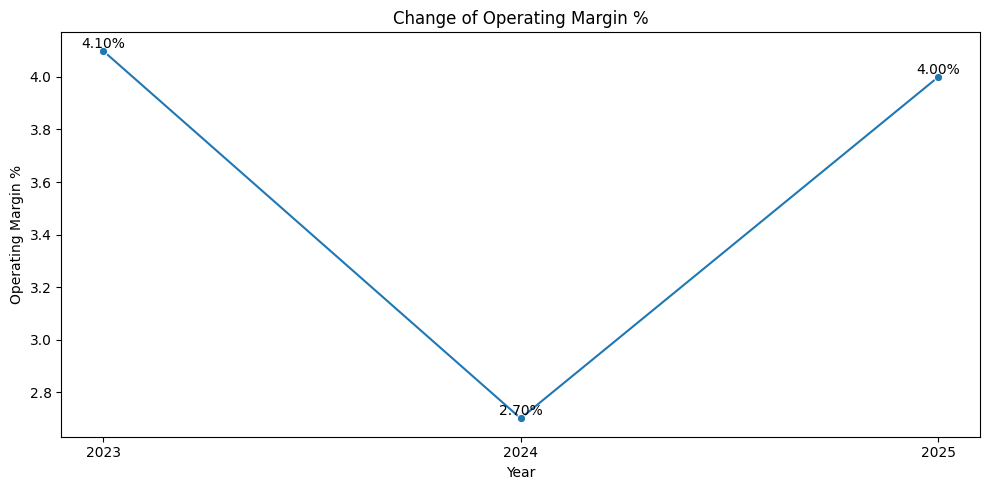

--- Ανάλυση για την εταιρεία: KSS ---
[2024] ΠΤΩΣΗ ΠΕΡΙΘΩΡΙΟΥ στο 2.7% (Έχασε 1.4 μονάδες)
    Αιτία:
    Το Μεταβλητό Κόστος (COGS) μειώθηκε κατά 6.3%, ενώ τα Έσοδα μειώθηκαν κατά 7.2%.
[2025] ΑΝΑΚΑΜΨΗ ΠΕΡΙΘΩΡΙΟΥ στο 4.0% (Κέρδισε 1.3 μονάδες)
    Αιτία:
    Τα Έσοδα μειώθηκαν κατά 4.3%, ενώ το Κόστος (COGS) μειώθηκε κατά 6.1%.


╒═══════════════════╤═════════════════╤═══════════════════╕
│   Fiscal_Year_Num │   Total_Revenue │   Cost_Of_Revenue │
╞═══════════════════╪═════════════════╪═══════════════════╡
│              2023 │      1.7476e+10 │        1.5521e+10 │
├───────────────────┼─────────────────┼───────────────────┤
│              2024 │      1.6221e+10 │        1.455e+10  │
├───────────────────┼─────────────────┼───────────────────┤
│              2025 │      1.5527e+10 │        1.3665e+10 │
╘═══════════════════╧═════════════════╧═══════════════════╛


In [52]:
Operating_Marg = df_final[["Ticker","Fiscal_Year_Num","Operating_Margin%","Cost_Of_Revenue","Operating_Expenses","Total_Revenue"]].copy()

Operating_Marg["Operating_Margin%_Growth"] = (round(Operating_Marg.groupby("Ticker")["Operating_Margin%"].pct_change(),2))

Operating_Marg_plot = Operating_Marg[(Operating_Marg["Ticker"] == "KSS")]
print(f"Υπηρξε αρνητικη μεταβολη στο  Λειτουτγικο περιθωριο για την εταιρια Kohl's απο το 2023 το 2024 της ταξης του {abs(Operating_Marg_plot["Operating_Margin%_Growth"].iloc[1])} ")

plt.figure(figsize=(10, 5))

ax = sns.lineplot(
    data=Operating_Marg_plot,
    x="Fiscal_Year_Num",
    y="Operating_Margin%",
    marker="o",
)

for _, row in Operating_Marg_plot.iterrows():
    ax.text(
        row["Fiscal_Year_Num"],
        row["Operating_Margin%"],
        f'{row["Operating_Margin%"]:.2f}%',
        ha="center",
        va="bottom",
        fontsize=10,
    )

plt.xlabel("Year")
plt.ylabel("Operating Margin %")
plt.title("Change of Operating Margin %")
plt.tight_layout()
plt.show()

df_KSS = df_final[df_final["Ticker"] == "KSS"].copy()

def analyze_margin_fluctuations(df):
   
    
  


    df = df.sort_values(by=['Ticker', 'Fiscal_Year_Num']).reset_index(drop=True)

   
    df['Revenue_Growth_%'] = df.groupby('Ticker')['Total_Revenue'].pct_change() * 100
    df['COGS_Growth_%'] = df.groupby('Ticker')['Cost_Of_Revenue'].pct_change() * 100
    
    

    df['Margin_Change'] = df.groupby('Ticker')['Operating_Margin%'].diff() 

    
    for ticker in df['Ticker'].unique():
        company_data = df[df['Ticker'] == ticker].dropna(subset=['Revenue_Growth_%'])
        
        if company_data.empty:
            continue
            
        print(f"--- Ανάλυση για την εταιρεία: {ticker} ---")
        
        for index, row in company_data.iterrows():
            year = row['Fiscal_Year_Num'] 
            margin = row['Operating_Margin%'] 
            margin_change = row['Margin_Change']
            rev_g = row['Revenue_Growth_%']
            cogs_g = row['COGS_Growth_%']
            
            
          
            cogs_word = "αυξήθηκε" if cogs_g >= 0 else "μειώθηκε"
            rev_word = "αυξήθηκαν" if rev_g >= 0 else "μειώθηκαν"
            
         
            if margin_change < -0.5:
                print(f"[{year}] ΠΤΩΣΗ ΠΕΡΙΘΩΡΙΟΥ στο {margin:.1f}% (Έχασε {abs(margin_change):.1f} μονάδες)")
                print(f"    Αιτία:")
                if cogs_g > rev_g:
                     print(f"    Το Μεταβλητό Κόστος (COGS) {cogs_word} κατά {abs(cogs_g):.1f}%, ενώ τα Έσοδα {rev_word} κατά {abs(rev_g):.1f}%.")
                else:
                     print(f"    Τα έσοδα {rev_word} ({abs(rev_g):.1f}%) ταχύτερα από όσο {cogs_word} τα κόστη ({abs(cogs_g):.1f}%).")
            
            
            elif margin_change > 0.5:
                print(f"[{year}] ΑΝΑΚΑΜΨΗ ΠΕΡΙΘΩΡΙΟΥ στο {margin:.1f}% (Κέρδισε {margin_change:.1f} μονάδες)")
                print(f"    Αιτία:")
                if rev_g > cogs_g:
                    print(f"    Τα Έσοδα {rev_word} κατά {abs(rev_g):.1f}%, ενώ το Κόστος (COGS) {cogs_word} κατά {abs(cogs_g):.1f}%.")
                else:
                     print(f"    Επιτυχής συγκράτηση κόστους. Το Κόστος (COGS) {cogs_word} ({abs(cogs_g):.1f}%) ταχύτερα από τα Έσοδα ({abs(rev_g):.1f}%).")
                    
        print("\n")

analyze_margin_fluctuations(df_KSS)


print(tabulate.tabulate( df_KSS[["Fiscal_Year_Num", "Total_Revenue", "Cost_Of_Revenue"]], headers="keys", tablefmt="fancy_grid", showindex=False))

In [53]:
import plotly.graph_objects as go
df_margin_safety = df_final[df_final["Fiscal_Year_Num"] == "2025"]

df_margin = df_margin_safety[["Ticker","Margin of Safety%"]].copy()

df_margin = df_margin.sort_values(by= "Margin of Safety%",ascending= True)

fig = go.Figure(go.Waterfall(
    name = "Margin of Safety %",
    orientation = "v",
   
    measure = ["absolute"] * len(df_margin),
    x = df_margin['Ticker'],
    y = df_margin['Margin of Safety%'],
    text = df_margin['Margin of Safety%'].astype(str) + '%', 
    textposition = "outside",
    connector = {"line": {"color": "gray", "dash": "dot"}}, 
    totals= {"marker": {"color" : "deep sky blue"}}
))


fig.update_layout(
    title = dict(
        text="Margin of Safety (%) ανά Εταιρεία",
        font=dict(size=20)
    ),
    showlegend = False,
    plot_bgcolor='white',
    yaxis=dict(
        title='Margin of Safety (%)',
        zeroline=True,             
        zerolinewidth=2,          
        zerolinecolor='black',
        gridcolor='lightgray'
    ),
    xaxis=dict(title='Εταιρείες'),
    height=600 
)


fig.show()

In [54]:
from plotly.subplots import make_subplots
df_GPRO = df_final[df_final["Ticker"] == "GPRO"]

metrics = [
    'Total_Revenue', 'EBIT', 
     'Margin of Safety%', 
    'Operating_Margin%', 'Z_score',
     "Working_Capital"
]

subplot_titles = [
    "Total Revenue", "EBIT", 
    "Margin of Safety (%)", 
    "Operating Margin", "Z-Score",
    "Working_Capital"
]

colors = ['#1558d6', '#046e00', '#eaa937', '#c0151d', '#681da8', '#00CC96']



fig = make_subplots(
    rows=3, cols=2, 
    subplot_titles=subplot_titles,
    horizontal_spacing=0.1,  
    vertical_spacing=0.15     
)


row = 1
col = 1
for i, metric in enumerate(metrics):
   
    fig.add_trace(
        go.Scatter(
            x=df_GPRO['Fiscal_Year_Num'], 
            y=df_GPRO[metric],
            mode='lines+markers',
            name=metric,
            line=dict(color=colors[i], width=2),
            marker=dict(size=6)
        ),
        row=row, col=col
    )
    
    
    if metric in ['Margin of Safety%', 'EBIT', 'Operating_Margin%', 'Z_score','Working_Capital']:
        fig.add_hline(y=0, line_dash="dash", line_color="gray", row=row, col=col)
    
    
    col += 1
    if col > 2:
        col = 1
        row += 1

fig.update_layout(
    title=f"Dashboard Απόδοσης & Βιωσιμότητας: GPRO",
    title_font_size=20,
    height=900,  
    width=1500,
    showlegend=False, 
    plot_bgcolor='white',
    hovermode="x unified" 
)


fig.update_xaxes(showgrid=True, gridwidth=1, gridcolor='lightgray')
fig.update_yaxes(showgrid=True, gridwidth=1, gridcolor='lightgray')

fig.show()

In [55]:
df_GPRO

,Fiscal_Year_Num,Total_Revenue,Cost_Of_Revenue,EBIT,Total_Assets,Total_Liabilities,Current_Assets,Current_Liabilities,Retained_Earnings,Equity,...,VIX,sector,Contribution_Margin,BEP_Rev,Margin of Safety%,Operating_Margin%,YoY Revenue Growth,Debt_to_Equity,Working_Capital,Z_score
3,2023,1.005459e+09,681886000.0,-75463000.0,967951000.0,412105000.0,482591000.0,279094000.0,-249296000.0,555846000.0,...,12.45,Technology,0.321816,1.239950e+09,-23.3,-7.5,0.000000,0.741401,203497000.0,1.3
4,2024,8.014730e+08,530178000.0,-135033000.0,543678000.0,391989000.0,339245000.0,356267000.0,-681607000.0,151689000.0,...,17.35,Technology,0.338495,1.200394e+09,-49.8,-16.8,-0.202878,2.584162,-17022000.0,-0.7
5,2025,6.515420e+08,432376000.0,-83341000.0,427983000.0,351433000.0,252569000.0,277171000.0,-775094000.0,76550000.0,...,14.95,Technology,0.336380,8.993001e+08,-38.0,-12.8,-0.187069,4.590895,-24602000.0,-1.7


In [56]:
# Aπεικονιση νεκρου σημειου
fig = go.Figure()

fig.add_trace(
    go.Scatter(
        x=df_GPRO["Fiscal_Year_Num"],
        y=df_GPRO['Total_Revenue'],
        mode='lines+markers',
        name='Πραγματικά Έσοδα (Total Revenue)',
        line=dict(color='#1558d6', width=3),
        marker=dict(size=8)
    )
)

fig.add_trace(
    go.Scatter(
        x=df_GPRO["Fiscal_Year_Num"],
        y=df_GPRO['BEP_Rev'],
        mode='lines+markers',
        name='Όριο Επιβίωσης (Break-Even Revenue)',
        line=dict(color='#eaa937', width=3, dash='dash'), 
        marker=dict(size=8)
    )
)


fig.update_layout(
    title=f"Ανάλυση Νεκρού Σημείου (Break-Even)",
    title_font_size=20,
    xaxis_title='Οικονομικό Έτος',
    yaxis_title='Ποσό ($)',
    plot_bgcolor='white',
    hovermode='x unified', 
    
    legend=dict(
        yanchor="auto",
        y=1.1,
        xanchor="auto",
        x=0.01,
        bgcolor="rgba(255, 255, 255, 0.8)", #
        bordercolor="lightgray",
        borderwidth=1
        
    ),
    width = 1500,
    height = 600
    
)


fig.update_xaxes(showgrid=True, gridwidth=1, gridcolor='lightgray')
fig.update_yaxes(showgrid=True, gridwidth=1, gridcolor='lightgray')

# Εμφάνιση
fig.show()

ΣΥΜΠΕΡΑΣΜΑ:
παρατηρουμε οτι η εταιρια GPRO ακολουθει μια πτρωτικη πορεια στο διαστημα 2023-2025.Παρατηρειατια αρχικα μεγαλη μειωση στα εσοδα της εταιριας.Επισης δεν υπηρχε αναπτυξη στην εταριαι καθως ο ρυθμος αναπτυξης της ηταν αρνητικος μεταξυ 2024 και 2025.Υπηρχε επισης μια εντυπωσιακη μειωση στο κεφαλιο κινσηης στην επιχειρηση το μειωθηκε κατα 186475000.0$ Αυτο δειχνει οτι η εταιρια εχει
χασει την ικανοτηα της αμεσης ρεστοποιησης και απο το 2024 και μετα αδυνατςι να πληρωσει της βραχυπροθεσμες υποχρεωσεις της.Ακομη ο συντελεστης Ζ_score πεσει  παρα πολυ κατω απο το οριο του 1.10 Μαλσιτα το 2024 ηταν -0.7 και το 2025 -1.7 τη στιγμη που το 2023 ηταν 1.3.Αυτο δειχνει ξεκαθαρα οτι παρχει μεγαλη πιθανοτηατ πως υπαρχει σοβαρο προβλημα βιωσιμοτητας.Ακομη
το γεγονος οτι η επιχειρηση ειχε αρνητικο ποσοστο στο Operating Margin δειχνει πως  μεταξυ 2023-2025 υπηρχαν λειτουργικες ζημιες.Συνεπως τα εσοδα δεν εφταναν να καλυψον το κοστος παραγωγης.
Τελος οπως φαινεται και αποτ ο γραφημα η εταιρια μεσα στην τριετια δεν καταφερε να πιασει  το Revenue το οποιο θα την εκανε βιωσιμη.Αποτελει ξεκαθρα τον αδυναμο κρικο του χαρτοφυλακιου

In [57]:
df_final[df_final["Ticker"] == "FSLY" ]

,Fiscal_Year_Num,Total_Revenue,Cost_Of_Revenue,EBIT,Total_Assets,Total_Liabilities,Current_Assets,Current_Liabilities,Retained_Earnings,Equity,...,VIX,sector,Contribution_Margin,BEP_Rev,Margin of Safety%,Operating_Margin%,YoY Revenue Growth,Debt_to_Equity,Working_Capital,Z_score
0,2023,505988000.0,239660000.0,-198028000.0,1.525191e+09,545703000.0,463673000.0,147694000.0,-8.347520e+08,979488000.0,...,12.45,Technology,0.526352,8.822150e+08,-74.4,-39.1,0.000000,0.557131,315979000.0,0.6
1,2024,543676000.0,247738000.0,-167915000.0,1.451359e+09,486109000.0,440195000.0,104456000.0,-9.928100e+08,965250000.0,...,17.35,Technology,0.544328,8.521574e+08,-56.7,-30.9,0.074484,0.503609,335739000.0,0.5
2,2025,624018000.0,267815000.0,-119000000.0,1.499477e+09,569899000.0,506709000.0,193998000.0,-1.114487e+09,929578000.0,...,14.95,Technology,0.570822,8.324894e+08,-33.4,-19.1,0.147776,0.613073,312711000.0,0.3


In [58]:
df_dang = df_final[["Fiscal_Year_Num","Ticker","YoY Revenue Growth","Z_score"]].copy()


df_dang.loc[:,"YoY Revenue Growth"] = round(df_dang.loc[:,"YoY Revenue Growth"],3)
df_dang[(df_dang['Z_score'].diff() < 0) & (df_dang['YoY Revenue Growth'].diff() > 0)]

df_red = df_final[df_final["Ticker"] == "FSLY" ]




print(tabulate.tabulate(df_red[["Total_Revenue","BEP_Rev","Operating_Margin%","YoY Revenue Growth","Debt_to_Equity","Z_score"]],headers= "keys",tablefmt= "fancy_grid"))

╒════╤═════════════════╤═════════════╤═════════════════════╤══════════════════════╤══════════════════╤═══════════╕
│    │   Total_Revenue │     BEP_Rev │   Operating_Margin% │   YoY Revenue Growth │   Debt_to_Equity │   Z_score │
╞════╪═════════════════╪═════════════╪═════════════════════╪══════════════════════╪══════════════════╪═══════════╡
│  0 │     5.05988e+08 │ 8.82215e+08 │               -39.1 │             0        │         0.557131 │       0.6 │
├────┼─────────────────┼─────────────┼─────────────────────┼──────────────────────┼──────────────────┼───────────┤
│  1 │     5.43676e+08 │ 8.52157e+08 │               -30.9 │             0.074484 │         0.503609 │       0.5 │
├────┼─────────────────┼─────────────┼─────────────────────┼──────────────────────┼──────────────────┼───────────┤
│  2 │     6.24018e+08 │ 8.32489e+08 │               -19.1 │             0.147776 │         0.613073 │       0.3 │
╘════╧═════════════════╧═════════════╧═════════════════════╧════════════════════

ΣΥΜΠΕΡΑΣΜΑ: η εταιρια δειχνει πως αναπτυσσεται ομως ο δεικτης z_score την εχει σταθερα κατω του κρισιμου οριο 1.10  δηαλδη η πιθανοτητα χρεωκοπιας ειναι μονιμως
υψηλη.Η εταιρια οπως φαινεται δεν εχει καταφερει να πιασει το revenue που θα την κανει βιωσιμη και εχει επισης λειτουργικες ζημιες γεγονος πο δειχνει 
πρωτον οτι η επιχειρηση εχει θεμα ρεστοτητας και αδυνατει να ξεπληρωσει τις βραχυπροθεσμες υποχρεωσεις της.Οπως φαινεται και απο τον δεικτη Debt to Equit
πανω απο το 50% αυτό υποδηλώνει ότι η εταιρεία στηρίζεται σε δανεισμό ο οποίος, εν απουσία λειτουργικών κερδών, λειτουργεί ως επιπλέον «βαρίδι», καθιστώντας την κεφαλαιακή της δομή εξαιρετικά επισφαλή

# Machine Learning Part

In [59]:
df_final["Is_Distressed"] = np.where( df_final["Z_score"] > 1.10,0,1)


INFO | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


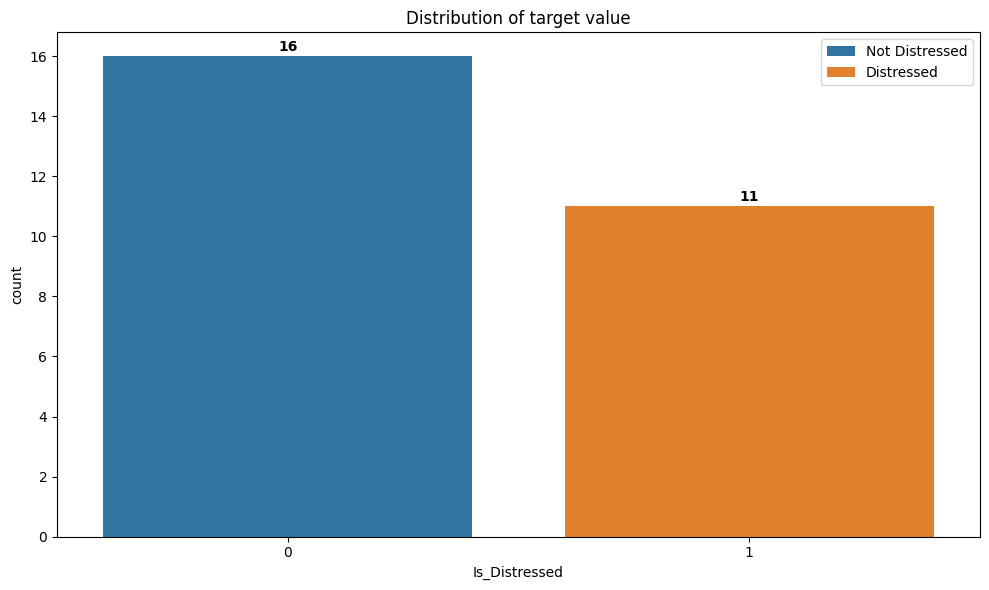

In [60]:
#Distribution of target value
plt.figure(figsize = (10,6))
ax = sns.countplot(data = df_final, x = 'Is_Distressed', hue = 'Is_Distressed')
plt.title("Distribution of target value")
plt.legend(
    ["Not Distressed",
     "Distressed"]
)

for container in ax.containers:
    ax.bar_label(container, fmt="%d", padding=2, fontsize=10, fontweight="bold")

plt.tight_layout()
plt.show()

In [61]:
df_final

,Fiscal_Year_Num,Total_Revenue,Cost_Of_Revenue,EBIT,Total_Assets,Total_Liabilities,Current_Assets,Current_Liabilities,Retained_Earnings,Equity,...,sector,Contribution_Margin,BEP_Rev,Margin of Safety%,Operating_Margin%,YoY Revenue Growth,Debt_to_Equity,Working_Capital,Z_score,Is_Distressed
0,2023,5.059880e+08,2.396600e+08,-198028000.0,1.525191e+09,5.457030e+08,4.636730e+08,1.476940e+08,-8.347520e+08,9.794880e+08,...,Technology,0.526352,8.822150e+08,-74.4,-39.1,0.000000,0.557131,3.159790e+08,0.6,1
1,2024,5.436760e+08,2.477380e+08,-167915000.0,1.451359e+09,4.861090e+08,4.401950e+08,1.044560e+08,-9.928100e+08,9.652500e+08,...,Technology,0.544328,8.521574e+08,-56.7,-30.9,0.074484,0.503609,3.357390e+08,0.5,1
2,2025,6.240180e+08,2.678150e+08,-119000000.0,1.499477e+09,5.698990e+08,5.067090e+08,1.939980e+08,-1.114487e+09,9.295780e+08,...,Technology,0.570822,8.324894e+08,-33.4,-19.1,0.147776,0.613073,3.127110e+08,0.3,1
3,2023,1.005459e+09,6.818860e+08,-75463000.0,9.679510e+08,4.121050e+08,4.825910e+08,2.790940e+08,-2.492960e+08,5.558460e+08,...,Technology,0.321816,1.239950e+09,-23.3,-7.5,0.000000,0.741401,2.034970e+08,1.3,0
4,2024,8.014730e+08,5.301780e+08,-135033000.0,5.436780e+08,3.919890e+08,3.392450e+08,3.562670e+08,-6.816070e+08,1.516890e+08,...,Technology,0.338495,1.200394e+09,-49.8,-16.8,-0.202878,2.584162,-1.702200e+07,-0.7,1
5,2025,6.515420e+08,4.323760e+08,-83341000.0,4.279830e+08,3.514330e+08,2.525690e+08,2.771710e+08,-7.750940e+08,7.655000e+07,...,Technology,0.336380,8.993001e+08,-38.0,-12.8,-0.187069,4.590895,-2.460200e+07,-1.7,1
6,2023,1.747600e+10,1.552101e+10,717000000.0,1.400900e+10,1.011600e+10,3.410000e+09,2.612000e+09,2.934000e+09,3.893000e+09,...,Consumer Cyclical,0.111867,1.106662e+10,36.7,4.1,0.000000,2.598510,7.980000e+08,2.2,0
7,2024,1.622100e+10,1.455001e+10,433000000.0,1.355900e+10,9.757000e+09,3.388000e+09,3.131000e+09,1.008000e+09,3.802000e+09,...,Consumer Cyclical,0.103014,1.201770e+10,25.9,2.7,-0.071813,2.566281,2.570000e+08,1.6,0
8,2025,1.552700e+10,1.366501e+10,624000000.0,1.336200e+10,9.314000e+09,3.691000e+09,2.531000e+09,1.223000e+09,4.048000e+09,...,Consumer Cyclical,0.119920,1.032352e+10,33.5,4.0,-0.042784,2.300889,1.160000e+09,1.7,0
9,2022,1.809365e+09,3.088640e+08,262508000.0,3.760993e+09,3.350458e+09,2.937070e+08,4.380370e+08,4.722660e+08,4.105350e+08,...,Consumer Cyclical,0.829297,1.492823e+09,17.5,14.5,0.000000,8.161199,-1.443300e+08,1.0,1


In [62]:
#
df_ml = df_final[["Total_Revenue","Cost_Of_Revenue","EBIT","Total_Assets","Total_Liabilities","Current_Assets","Current_Liabilities",
                  "Retained_Earnings","Equity","Gross_Profit","Operating_Expenses","SP500","Interest_Rate_10Yr","VIX","sector","Contribution_Margin",
                  "BEP_Rev","Margin of Safety%","Operating_Margin%","YoY Revenue Growth","Working_Capital","Is_Distressed"

]]

In [63]:
df_ml

,Total_Revenue,Cost_Of_Revenue,EBIT,Total_Assets,Total_Liabilities,Current_Assets,Current_Liabilities,Retained_Earnings,Equity,Gross_Profit,...,Interest_Rate_10Yr,VIX,sector,Contribution_Margin,BEP_Rev,Margin of Safety%,Operating_Margin%,YoY Revenue Growth,Working_Capital,Is_Distressed
0,5.059880e+08,2.396600e+08,-198028000.0,1.525191e+09,5.457030e+08,4.636730e+08,1.476940e+08,-8.347520e+08,9.794880e+08,2.663280e+08,...,3.88,12.45,Technology,0.526352,8.822150e+08,-74.4,-39.1,0.000000,3.159790e+08,1
1,5.436760e+08,2.477380e+08,-167915000.0,1.451359e+09,4.861090e+08,4.401950e+08,1.044560e+08,-9.928100e+08,9.652500e+08,2.959380e+08,...,4.58,17.35,Technology,0.544328,8.521574e+08,-56.7,-30.9,0.074484,3.357390e+08,1
2,6.240180e+08,2.678150e+08,-119000000.0,1.499477e+09,5.698990e+08,5.067090e+08,1.939980e+08,-1.114487e+09,9.295780e+08,3.562030e+08,...,4.18,14.95,Technology,0.570822,8.324894e+08,-33.4,-19.1,0.147776,3.127110e+08,1
3,1.005459e+09,6.818860e+08,-75463000.0,9.679510e+08,4.121050e+08,4.825910e+08,2.790940e+08,-2.492960e+08,5.558460e+08,3.235730e+08,...,3.88,12.45,Technology,0.321816,1.239950e+09,-23.3,-7.5,0.000000,2.034970e+08,0
4,8.014730e+08,5.301780e+08,-135033000.0,5.436780e+08,3.919890e+08,3.392450e+08,3.562670e+08,-6.816070e+08,1.516890e+08,2.712950e+08,...,4.58,17.35,Technology,0.338495,1.200394e+09,-49.8,-16.8,-0.202878,-1.702200e+07,1
5,6.515420e+08,4.323760e+08,-83341000.0,4.279830e+08,3.514330e+08,2.525690e+08,2.771710e+08,-7.750940e+08,7.655000e+07,2.191660e+08,...,4.18,14.95,Technology,0.336380,8.993001e+08,-38.0,-12.8,-0.187069,-2.460200e+07,1
6,1.747600e+10,1.552101e+10,717000000.0,1.400900e+10,1.011600e+10,3.410000e+09,2.612000e+09,2.934000e+09,3.893000e+09,1.954993e+09,...,4.03,13.85,Consumer Cyclical,0.111867,1.106662e+10,36.7,4.1,0.000000,7.980000e+08,0
7,1.622100e+10,1.455001e+10,433000000.0,1.355900e+10,9.757000e+09,3.388000e+09,3.131000e+09,1.008000e+09,3.802000e+09,1.670993e+09,...,4.58,16.43,Consumer Cyclical,0.103014,1.201770e+10,25.9,2.7,-0.071813,2.570000e+08,0
8,1.552700e+10,1.366501e+10,624000000.0,1.336200e+10,9.314000e+09,3.691000e+09,2.531000e+09,1.223000e+09,4.048000e+09,1.861993e+09,...,4.26,17.44,Consumer Cyclical,0.119920,1.032352e+10,33.5,4.0,-0.042784,1.160000e+09,0
9,1.809365e+09,3.088640e+08,262508000.0,3.760993e+09,3.350458e+09,2.937070e+08,4.380370e+08,4.722660e+08,4.105350e+08,1.500501e+09,...,3.52,18.51,Consumer Cyclical,0.829297,1.492823e+09,17.5,14.5,0.000000,-1.443300e+08,1


In [64]:
TARGET = df_ml["Is_Distressed"]
X = df_ml.drop(["Is_Distressed"],axis = 1)
y = TARGET

In [65]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size= 0.2,random_state= 42)

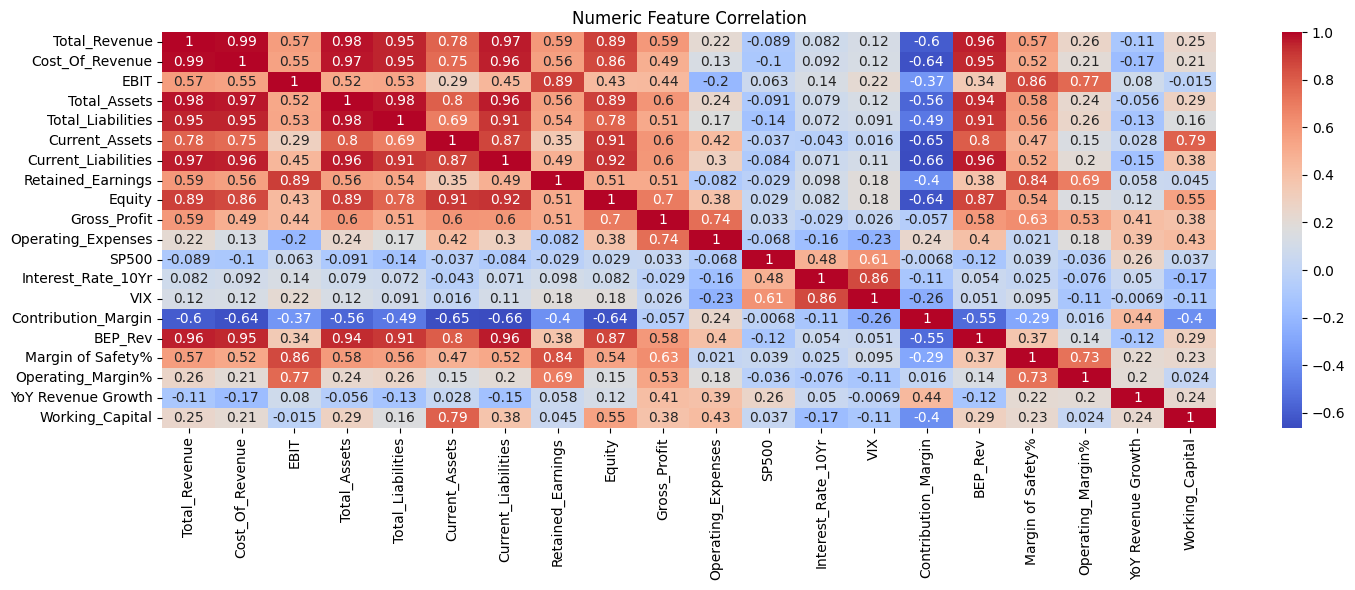

In [66]:
num_f = X_train.select_dtypes(include= "float64").columns.to_list()

corr_matrx =  X_train[num_f].corr()

plt.figure(figsize= (15,6))
sns.heatmap(corr_matrx,annot= True,cmap = "coolwarm")
plt.title("Numeric Feature Correlation")
plt.tight_layout()
plt.show()

In [67]:
from sklearn.feature_selection import f_classif,chi2
a = 0.05
X_train_num =  X_train[num_f]
f_scores,p_value = f_classif(X_train_num,y_train)
p_val = pd.Series(p_value,index = num_f)
selected_features = p_val[p_val < a].index


X_train_p_num = X_train[selected_features]
X_test_p_num= X_test[selected_features]

print(f"Original numeric features: {len(num_f)}")
print(f"Selected significant features: {len(selected_features)}")
print("Selected columns:", selected_features.tolist())


Original numeric features: 20
Selected significant features: 11
Selected columns: ['Total_Revenue', 'Cost_Of_Revenue', 'EBIT', 'Current_Assets', 'Current_Liabilities', 'Retained_Earnings', 'Equity', 'Gross_Profit', 'Contribution_Margin', 'Margin of Safety%', 'Operating_Margin%']


In [68]:
from sklearn.preprocessing import OrdinalEncoder
catf = X_train.select_dtypes(include= "object").columns.to_list()
a = 0.05
encoder = OrdinalEncoder()

X_train_cat = X_train[catf]
X_train_cat_encoded = encoder.fit_transform(X_train_cat)
chi2_stat,p_value_cat = chi2(X_train_cat_encoded ,y_train)

p_val_cat = pd.Series(p_value_cat, index=catf)


selected_cat_features = p_val_cat[p_val_cat < a].index

print(f"Original categorical features: {len(catf)}")
print(f"Selected significant categorical features: {len(selected_cat_features)}")
print("Selected columns:", selected_cat_features.tolist())


Original categorical features: 1
Selected significant categorical features: 0
Selected columns: []


In [69]:
X_train_final = X_train_p_num.copy()
X_test_final = X_test_p_num.copy()

In [70]:
X_train_final

,Total_Revenue,Cost_Of_Revenue,EBIT,Current_Assets,Current_Liabilities,Retained_Earnings,Equity,Gross_Profit,Contribution_Margin,Margin of Safety%,Operating_Margin%
16,1.252608e+09,0.000000e+00,3038000.0,3.682160e+08,1.873130e+08,2.698400e+07,4.700180e+08,1.252608e+09,1.000000,0.2,0.2
17,1.445306e+09,0.000000e+00,62508000.0,4.303470e+08,2.449180e+08,7.270900e+07,5.253270e+08,1.445306e+09,1.000000,4.3,4.3
12,3.484619e+09,1.962004e+09,-792377000.0,3.072942e+09,1.275527e+09,-1.297587e+09,2.326333e+09,1.522615e+09,0.436953,-52.0,-22.7
24,1.658713e+09,7.155270e+08,225458000.0,9.144050e+08,3.983530e+08,4.384360e+08,7.236100e+08,9.431860e+08,0.568625,-31.3,13.6
1,5.436760e+08,2.477380e+08,-167915000.0,4.401950e+08,1.044560e+08,-9.928100e+08,9.652500e+08,2.959380e+08,0.544328,-56.7,-30.9
4,8.014730e+08,5.301780e+08,-135033000.0,3.392450e+08,3.562670e+08,-6.816070e+08,1.516890e+08,2.712950e+08,0.338495,-49.8,-16.8
5,6.515420e+08,4.323760e+08,-83341000.0,2.525690e+08,2.771710e+08,-7.750940e+08,7.655000e+07,2.191660e+08,0.336380,-38.0,-12.8
2,6.240180e+08,2.678150e+08,-119000000.0,5.067090e+08,1.939980e+08,-1.114487e+09,9.295780e+08,3.562030e+08,0.570822,-33.4,-19.1
15,1.087533e+09,0.000000e+00,5921000.0,3.344320e+08,1.640670e+08,1.677700e+07,4.434170e+08,1.087533e+09,1.000000,0.5,0.5
22,5.550666e+09,3.619395e+09,473764000.0,1.492796e+09,1.075679e+09,2.503068e+09,2.471504e+09,1.926670e+09,0.347935,35.9,8.5


In [71]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

num_pipe = Pipeline(
    steps = [("scaler",StandardScaler())]
)

num_f_sel = X_train_final.columns.to_list()
preprocessor = ColumnTransformer(
    transformers=[("num",num_pipe,num_f_sel)
    ],
    remainder="drop"
)



In [72]:
# model selection
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

pos = (y_train == 1).sum()
neg = (y_train == 0).sum()
scale_pos_weight = neg / max(pos, 1)

models = {
    "LogisticRegression" : LogisticRegression(
        random_state= 42,
        max_iter= 1000,
        class_weight= "balanced"
    ),
    
    "RandomForestClassifier": RandomForestClassifier(
        n_estimators=300,      
        max_depth=15,        
        min_samples_split=5,   
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1,
        class_weight='balanced' 
    ),
  
"XGBClassifier": XGBClassifier(
        n_estimators=500,     
        learning_rate=0.05,   
        subsample=0.8,
        colsample_bytree=0.8,
        max_depth = 5,
        random_state=42,
        n_jobs=-1,
        tree_method="hist",
        objective='binary:logistic', 
        eval_metric='logloss',
        scale_pos_weight = scale_pos_weight
               
       
    ),

}

In [73]:
from sklearn.model_selection import StratifiedKFold,cross_validate
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results_cv = []
scoring = {
    "accuracy": "accuracy",
    "f1": "f1",            
    "precision": "precision",
    "recall": "recall",
    "roc_auc": "roc_auc"  
}

for model_name, model in models.items():
    
    model_pipeline = Pipeline(steps = [
        ("preprocessor",preprocessor),
        ("classifier",model)
    ])
    
    cv_res = cross_validate(
        model_pipeline,
        X_train_final,
        y_train,
        cv = cv,
        scoring= scoring,
        n_jobs= -1
    )

    results_cv.append({
        "model": model_name,
        "accuracy_mean":  cv_res["test_accuracy"].mean(),
        "f1_mean":        cv_res["test_f1"].mean(),    
        "roc_auc_mean":   cv_res["test_roc_auc"].mean(),
        "precision_mean": cv_res["test_precision"].mean(),
        "recall_mean":    cv_res["test_recall"].mean(),
        "f1_std":         cv_res["test_f1"].std()       
    })
    
cv_summary = pd.DataFrame(results_cv)
cv_summary = cv_summary.sort_values(by="recall_mean", ascending=False)

print("\nCross-Validation Results (Sorted by F1_mean Score):")
print(cv_summary)


Cross-Validation Results (Sorted by F1_mean Score):
                    model  accuracy_mean   f1_mean  roc_auc_mean  \
0      LogisticRegression           0.82  0.666667      0.883333   
1  RandomForestClassifier           0.78  0.647619      1.000000   
2           XGBClassifier           0.78  0.647619      1.000000   

   precision_mean  recall_mean    f1_std  
0            0.70          0.7  0.365148  
1            0.68          0.7  0.367130  
2            0.68          0.7  0.367130  


In [74]:
# 1. Ορίζουμε το τελικό Pipeline που περιλαμβάνει ΚΑΙ το scaling ΚΑΙ το μοντέλο
model_log = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(random_state=42, max_iter=1000, class_weight="balanced"))
])

model_log.fit(X_train_final, y_train)

y_pred = model_log.predict(X_test_final)

y_probs = model_log.predict_proba(X_test_final)[:, 1]


FINAL TEST SET PERFORMANCE
Accuracy: 83.33%
ROC AUC:  1.0000

Classification Report:
              precision    recall  f1-score   support

           0       0.75      1.00      0.86         3
           1       1.00      0.67      0.80         3

    accuracy                           0.83         6
   macro avg       0.88      0.83      0.83         6
weighted avg       0.88      0.83      0.83         6



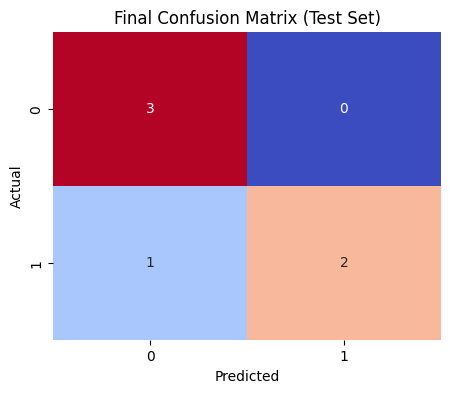

In [75]:
from sklearn.metrics import classification_report, confusion_matrix,accuracy_score,roc_auc_score
cm = confusion_matrix(y_test, y_pred)


print("\n" + "="*40)
print("FINAL TEST SET PERFORMANCE")
print("="*40)

acc = accuracy_score(y_test, y_pred)
roc = roc_auc_score(y_test, model_log.predict_proba(X_test_final)[:, 1])

print(f"Accuracy: {acc:.2%}")
print(f"ROC AUC:  {roc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Δημιουργία Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='coolwarm', cbar=False)
plt.title("Final Confusion Matrix (Test Set)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


ΑΠΟΤΕΛΕΣΜΑΤΑ ΜΕ ΠΡΟΣΑΡΜΟΣΜΕΝΟ THRESHOLD: 0.35

Νέο Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.67      0.80         3
           1       0.75      1.00      0.86         3

    accuracy                           0.83         6
   macro avg       0.88      0.83      0.83         6
weighted avg       0.88      0.83      0.83         6



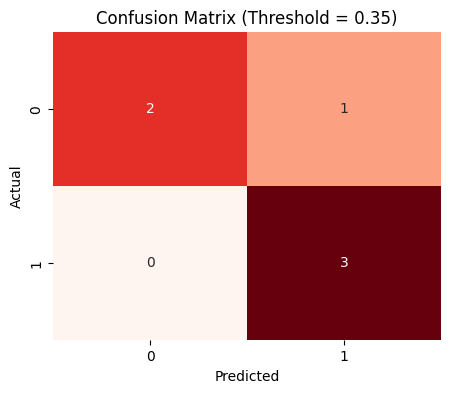

In [76]:
y_probs = model_log.predict_proba(X_test_final)[:, 1]


custom_threshold = 0.35


y_pred_custom = (y_probs >= custom_threshold).astype(int)


print("\n" + "="*50)
print(f"ΑΠΟΤΕΛΕΣΜΑΤΑ ΜΕ ΠΡΟΣΑΡΜΟΣΜΕΝΟ THRESHOLD: {custom_threshold}")
print("="*50)

print("\nΝέο Classification Report:")
print(classification_report(y_test, y_pred_custom))


cm_custom = confusion_matrix(y_test, y_pred_custom)
plt.figure(figsize=(5, 4))

sns.heatmap(cm_custom, annot=True, fmt='d', cmap='Reds', cbar=False)
plt.title(f"Confusion Matrix (Threshold = {custom_threshold})")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

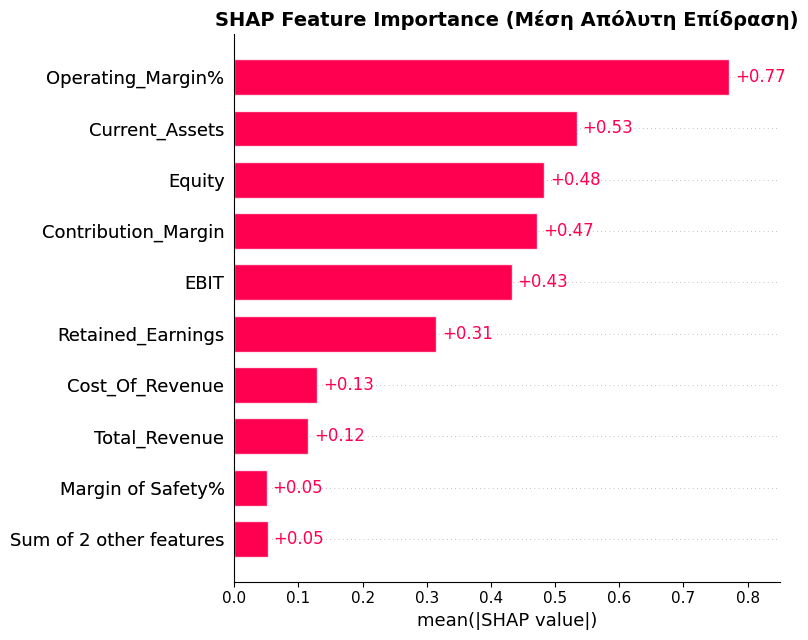

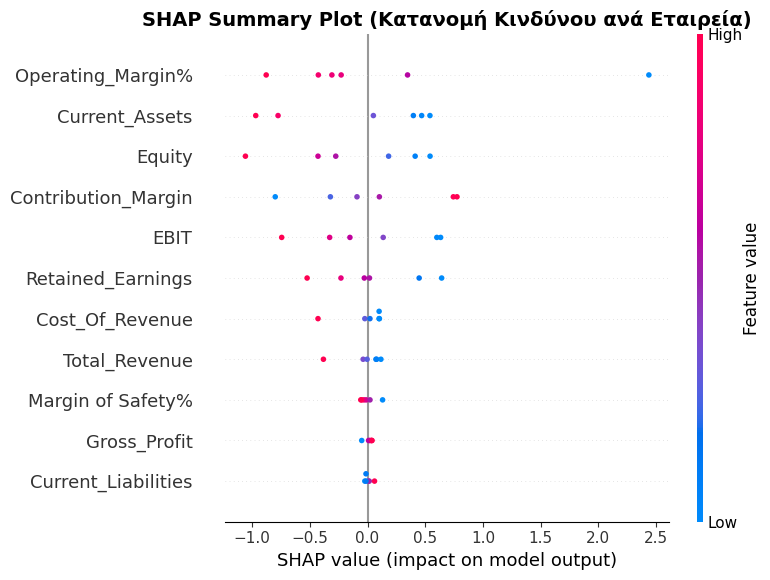

In [77]:
import shap
prepoc = model_log.named_steps["preprocessor"]
trained_model = model_log.named_steps['classifier']

X_train_scaled = preprocessor.transform(X_train_final)
X_test_scaled  = preprocessor.transform(X_test_final)


feature_names = X_train_final.columns.tolist()

explainer = shap.LinearExplainer(trained_model,X_train_scaled)

shap_values = explainer(X_test_scaled)

shap_values.feature_names = feature_names


plt.figure(figsize=(8, 6))
plt.title("SHAP Feature Importance (Μέση Απόλυτη Επίδραση)", fontsize=14, fontweight='bold')
shap.plots.bar(shap_values, show=False)
plt.tight_layout()
plt.show()


plt.figure(figsize=(10, 6))
plt.title("SHAP Summary Plot (Κατανομή Κινδύνου ανά Εταιρεία)", fontsize=14, fontweight='bold')
shap.summary_plot(shap_values.values, X_test_scaled, feature_names=feature_names, show=False)
plt.tight_layout()
plt.show()

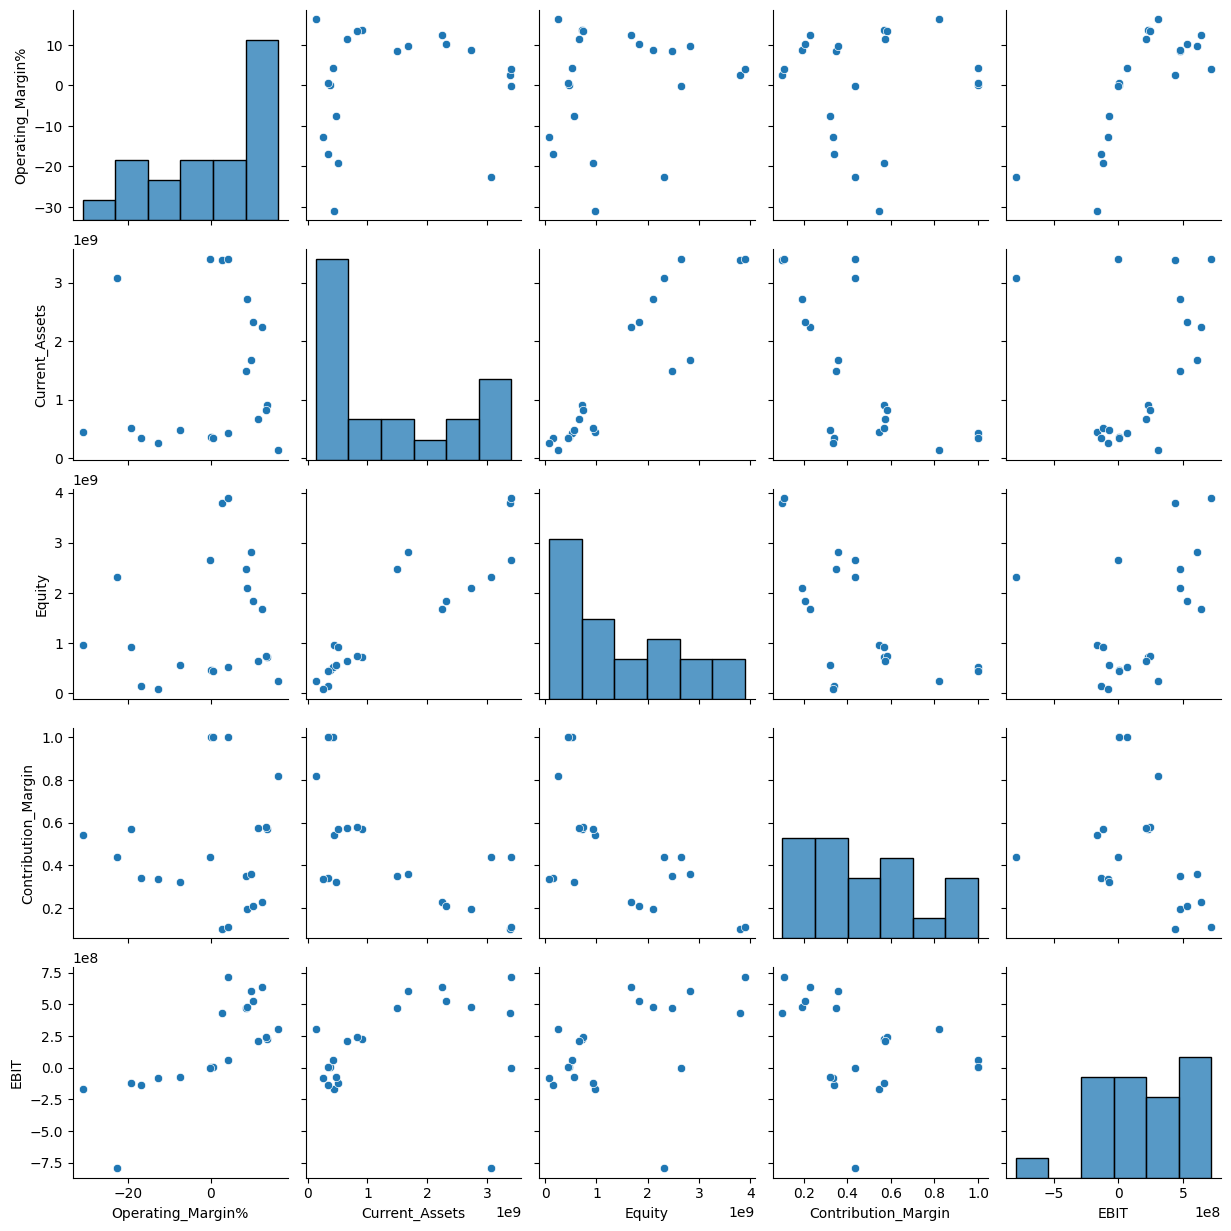

In [78]:
import scipy.stats as st
top_5_features = [
    'Operating_Margin%',
    'Current_Assets',
    'Equity',
    'Contribution_Margin',
    'EBIT'
]
sns.pairplot(X_train_final[top_5_features])
plt.show()

In [ ]:
import numpy as np, pandas as pd

base = df_final[df_final["Ticker"] == "YETI"].iloc[-1]
N = 10000; rng = np.random.default_rng(42)


opex = base["Total_Revenue"] - base["Cost_Of_Revenue"] - base["EBIT"]

base_prob = model_log.predict_proba(df_ml.loc[[base.name], X_train_final.columns])[:, 1][0]

revenue = base["Total_Revenue"]   * (1 + rng.normal(0, 0.15, N))
cogs    = base["Cost_Of_Revenue"] * (1 + rng.normal(0, 0.10, N))
ebit           = revenue - cogs - opex
op_margin      = (ebit / revenue) * 100
contrib_marg   = np.clip((revenue - cogs) / revenue, None, 1.0)
current_assets = (base["Current_Assets"] * (1 + rng.normal(0, 0.10, N))).clip(min=0)
equity         =  base["Equity"]         * (1 + rng.normal(0, 0.10, N))
gross_profit   = revenue - cogs
mos            = ((revenue - opex / contrib_marg) / revenue) * 100

synthetic_data = pd.DataFrame({
    "Total_Revenue": revenue, "Cost_Of_Revenue": cogs, "EBIT": ebit,
    "Current_Assets": current_assets, "Current_Liabilities": base["Current_Liabilities"],
    "Retained_Earnings": base["Retained_Earnings"], "Equity": equity,
    "Gross_Profit": gross_profit, "Contribution_Margin": contrib_marg,
    "Margin of Safety%": mos, "Operating_Margin%": op_margin,
})[X_train_final.columns]

mc_probabilities = model_log.predict_proba(synthetic_data)[:, 1]
ruin_threshold = 0.35
ruin_proba = (mc_probabilities >= ruin_threshold).mean()
assert abs(synthetic_data["EBIT"].mean() - base["EBIT"]) < 0.2 * abs(base["EBIT"]), "ακόμη λάθος!"
print("synthetic EBIT mean:", f"{synthetic_data['EBIT'].mean():,.0f}", "| YETI base:", f"{base['EBIT']:,.0f}")
print("base_prob YETI:     ", f"{base_prob:.2%}")
print("MC mean distress:   ", f"{mc_probabilities.mean():.2%}", " (τώρα περιμένουμε ~30%)")
print("Probability of Ruin:", f"{ruin_proba:.2%}")

synthetic EBIT mean: 209,064,613 | YETI base: 213,557,000
base_prob YETI:      29.62%
MC mean distress:    34.55%  (τώρα περιμένουμε ~30%)
Probability of Ruin: 40.50%


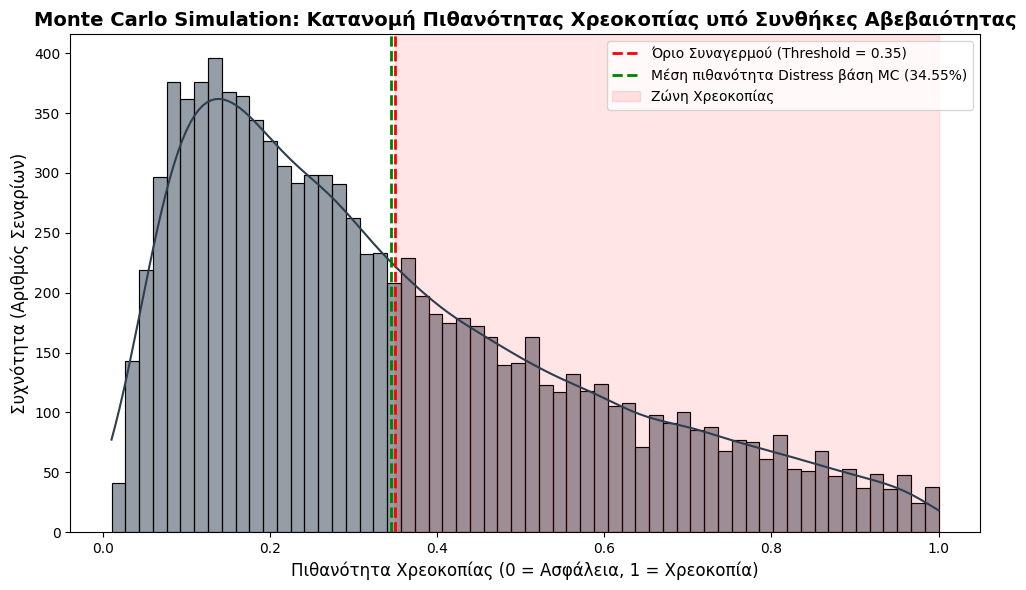

In [86]:
plt.figure(figsize=(10, 6))
sns.histplot(mc_probabilities, bins=60, kde=True, color='#2c3e50')
plt.axvline(x= ruin_threshold, color='red', linestyle='--', linewidth=2, label=f'Όριο Συναγερμού (Threshold = {ruin_threshold})')
plt.axvline(x = mc_probabilities.mean(),color = "green",linestyle = "--",linewidth = 2,label = f"Μέση πιθανότητα Distress βάση MC ({mc_probabilities.mean():.2%})" )
# Χρωματίζουμε την "Επικίνδυνη Ζώνη"
plt.axvspan(ruin_threshold, 1.0, color='red', alpha=0.1, label='Ζώνη Χρεοκοπίας')

plt.title('Monte Carlo Simulation: Κατανομή Πιθανότητας Χρεοκοπίας υπό Συνθήκες Αβεβαιότητας', 
          fontsize=14, fontweight='bold')
plt.xlabel('Πιθανότητα Χρεοκοπίας (0 = Ασφάλεια, 1 = Χρεοκοπία)', fontsize=12)
plt.ylabel('Συχνότητα (Αριθμός Σεναρίων)', fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()